In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.figure(figsize=(8, 8))

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

## 全景图像拼接

In [34]:
class Stitcher:

    def stitch(self, images, ratio=0.75, reprojThresh=4.0, showMatches=False):
        (imageB, imageA) = images
        #
        (kpsA, featuresA) = self.detectAndDescribe(imageA)
        (kpsB, featuresB) = self.detectAndDescribe(imageB)

        M = self.matchKeypoints(kpsA, kpsB, featuresA, featuresB, ratio, reprojThresh)

        if M is None:
            return None
        
        #
        (matches, H, status) = M
        result = cv2.warpPerspective(imageA, H, (imageA.shape[1] + imageB.shape[1], imageA.shape[0]))
        result[0:imageB.shape[0], 0:imageB.shape[1]] = imageB
        if showMatches:
            vis = self.drawMatches(imageA, imageB, kpsA, kpsB, matches, status)
            return (result, vis)
        return result, None
    
    def detectAndDescribe(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        descriptor = cv2.xfeatures2d.SIFT_create()
        (kps, features) = descriptor.detectAndCompute(image, None)
        #
        kps = np.float32([kp.pt for kp in kps])
        return (kps, features)
    
    def matchKeypoints(self, kpsA, kpsB, featuresA, featuresB, ratio, reprojThresh):
        matcher = cv2.BFMatcher()
        rawMatchers = matcher.knnMatch(featuresA, featuresB, 2)
        matches = []
        for m in rawMatchers:
            if len(m) == 2 and m[0].distance < m[1].distance * ratio:
                matches.append((m[0].trainIdx, m[0].queryIdx))
        # 投影变换矩阵至少需要 4 个点
        if len(matches) > 4:
            ptsA = np.float32([kpsA[i] for (_, i) in matches])
            ptsB = np.float32([kpsB[i] for (i, _) in matches])
            #
            (H, status) = cv2.findHomography(ptsA, ptsB, cv2.RANSAC, reprojThresh)
            return (matches, H, status)
        return None
    
    def drawMatches(self, imageA, imageB, kpsA, kpsB, matches, status):
        (hA, wA) = imageA.shape[:2]
        (hB, wB) = imageB.shape[:2]
        vis = np.zeros((max(hA, hB), wA + wB, 3), dtype = 'uint8')
        vis[0:hA, 0:wA] = imageA
        vis[0:hB, wA:] = imageB

        for ((trainIdx, queryIdx), s) in zip(matches, status):
            if s == 1:
                ptA = (int(kpsA[queryIdx][0]), int(kpsA[queryIdx][1]))
                ptB = (int(kpsB[trainIdx][0]) + wA, int(kpsB[trainIdx][1]))
                cv2.line(vis, ptA, ptB, (0, 255, 0), 1)
        return vis

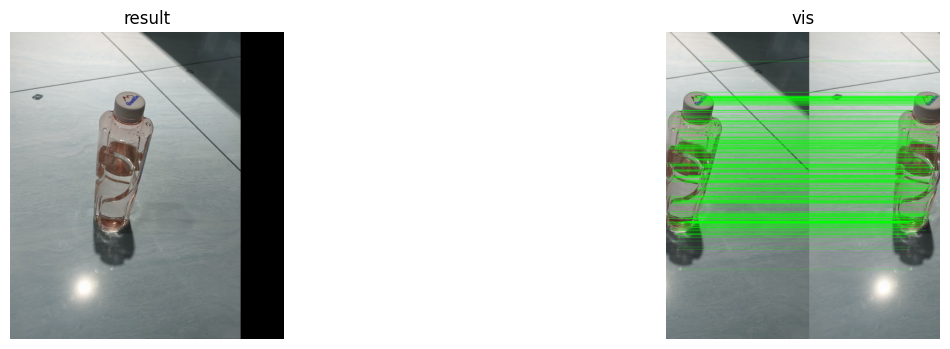

In [36]:
imageA = cv2.imread('./assets/1_left.jpg')
imageB = cv2.imread('./assets/1_right.jpg')

stitcher = Stitcher()
(result, vis) = stitcher.stitch([imageA, imageB], showMatches=True)

plt.figure(figsize=(12, 12))
plt.subplot(231), plt.imshow(result), plt.title("result"), plt.axis('off')
if vis is not None:
    plt.subplot(233), plt.imshow(vis), plt.title("vis"), plt.axis('off')